In [1]:
import numpy as np
import tikzplotlib
import math
import matplotlib.pyplot as plt
import torch
from torch.autograd.functional import jacobian
import sys
import copy
import pathlib
from pathlib import Path
cwd = Path().resolve()
import os
from os import path
# __file__ should be defined in this case
PARENT_DIR = path.dirname(cwd)
sys.path.append(PARENT_DIR)
import pickle as pkl

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/opt/anaconda3/envs/pytorch_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Metrics (NMSE, MSE) for different $\sigma_{e}^{2}$ (in dB) values for $\text{SMNR}=10.0 \text{ dB}$

In [2]:
import json
def load_metrics_json(file):
    with open(file, 'rb') as f:
        metrics = json.load(f)
    return metrics

In [3]:
ssm_type = "LorenzSSMn2"
dirname = "LorenzSSMn3x2"

In [4]:
'''
date="2024-12-02"
METRICSJSON_SemiDANSE_sigmae2_dict = {
    "-20.0dB": "../figs_new_{}_diff_sigma_e2_dB/LorenzSSMrn3x2/full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-20.0dB/{}_test_full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-20.0dB_nsup_20_T_2000_N_100_diff_sigmae2.json".format(date),
    "-10.0dB": "../figs_new_{}_diff_sigma_e2_dB/LorenzSSMrn3x2/full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-10.0dB/{}_test_full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-10.0dB_nsup_20_T_2000_N_100_diff_sigmae2.json".format(date),
    "-5.0dB": "../figs_new_{}_diff_sigma_e2_dB/LorenzSSMrn3x2/full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-5.0dB/{}_test_full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-5.0dB_nsup_20_T_2000_N_100_diff_sigmae2.json".format(date),
    "0.0dB": "../figs_new_{}_diff_sigma_e2_dB/LorenzSSMrn3x2/full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_0.0dB/{}_test_full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_0.0dB_nsup_20_T_2000_N_100_diff_sigmae2.json".format(date),
    "5.0dB": "../figs_new_{}_diff_sigma_e2_dB/LorenzSSMrn3x2/full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_5.0dB/{}_test_full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_5.0dB_nsup_20_T_2000_N_100_diff_sigmae2.json".format(date),   
}

METRICSJSON_SemiDANSE_sigmae2_matched_dict = {
    "-20.0dB": "../figs_new_{}_diff_sigma_e2_dB_matched/LorenzSSMrn3x2/full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-20.0dB/{}_test_full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-20.0dB_nsup_20_T_2000_N_100_diff_sigmae2.json".format(date),
    "-10.0dB": "../figs_new_{}_diff_sigma_e2_dB_matched/LorenzSSMrn3x2/full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-10.0dB/{}_test_full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-10.0dB_nsup_20_T_2000_N_100_diff_sigmae2.json".format(date),
    "-5.0dB": "../figs_new_{}_diff_sigma_e2_dB_matched/LorenzSSMrn3x2/full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-5.0dB/{}_test_full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-5.0dB_nsup_20_T_2000_N_100_diff_sigmae2.json".format(date),
    "0.0dB": "../figs_new_{}_diff_sigma_e2_dB_matched/LorenzSSMrn3x2/full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_0.0dB/{}_test_full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_0.0dB_nsup_20_T_2000_N_100_diff_sigmae2.json".format(date),
    "5.0dB": "../figs_new_{}_diff_sigma_e2_dB_matched/LorenzSSMrn3x2/full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_5.0dB/{}_test_full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_5.0dB_nsup_20_T_2000_N_100_diff_sigmae2.json".format(date),   
}
'''

'\ndate="2024-12-02"\nMETRICSJSON_SemiDANSE_sigmae2_dict = {\n    "-20.0dB": "../figs_new_{}_diff_sigma_e2_dB/LorenzSSMrn3x2/full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-20.0dB/{}_test_full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-20.0dB_nsup_20_T_2000_N_100_diff_sigmae2.json".format(date),\n    "-10.0dB": "../figs_new_{}_diff_sigma_e2_dB/LorenzSSMrn3x2/full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-10.0dB/{}_test_full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-10.0dB_nsup_20_T_2000_N_100_diff_sigmae2.json".format(date),\n    "-5.0dB": "../figs_new_{}_diff_sigma_e2_dB/LorenzSSMrn3x2/full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-5.0dB/{}_test_full_opt_diff_sigma_e2_dB_kappa_0.02_smnr_10.0dB_Ntrain_1000_Ttrain_100_sigma_e2_dB_nominal_-5.0dB_nsup_20_T_2000_N_1

In [5]:
# ((nmse, nmse_std, mse, mse_std, time), (ls,danse,danse_semisupervised), smnrs)
'''
metrics_semidanse_sigmae2_minus20_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_dict["-20.0dB"])['result_mat']) 
metrics_semidanse_sigmae2_minus10_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_dict["-10.0dB"])['result_mat']) 
metrics_semidanse_sigmae2_minus5_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_dict["-5.0dB"])['result_mat']) 
metrics_semidanse_sigmae2_0_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_dict["0.0dB"])['result_mat']) 
metrics_semidanse_sigmae2_5_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_dict["5.0dB"])['result_mat']) 

metrics_semidanse_sigmae2_minus20_matched_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_matched_dict["-20.0dB"])['result_mat']) 
metrics_semidanse_sigmae2_minus10_matched_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_matched_dict["-10.0dB"])['result_mat']) 
metrics_semidanse_sigmae2_minus_matched_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_matched_dict["-5.0dB"])['result_mat']) 
metrics_semidanse_sigmae2_0_matched_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_matched_dict["0.0dB"])['result_mat']) 
metrics_semidanse_sigmae2_5_matched_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_matched_dict["5.0dB"])['result_mat']) 
'''

'\nmetrics_semidanse_sigmae2_minus20_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_dict["-20.0dB"])[\'result_mat\']) \nmetrics_semidanse_sigmae2_minus10_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_dict["-10.0dB"])[\'result_mat\']) \nmetrics_semidanse_sigmae2_minus5_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_dict["-5.0dB"])[\'result_mat\']) \nmetrics_semidanse_sigmae2_0_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_dict["0.0dB"])[\'result_mat\']) \nmetrics_semidanse_sigmae2_5_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_dict["5.0dB"])[\'result_mat\']) \n\nmetrics_semidanse_sigmae2_minus20_matched_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_matched_dict["-20.0dB"])[\'result_mat\']) \nmetrics_semidanse_sigmae2_minus10_matched_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_sigmae2_matched_dict["-10.0dB"])[\'result_mat\

### Creating plot NMSE vs. SMNR for PF, pDANSE ($\kappa=0\%$) 

In [6]:
'''
kappas = np.array([-20.0, -10.0, -5.0, 0.0, 5.0])
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})
plt.figure(figsize=(8,6))

plt.errorbar(
    kappas,
    metrics_semidanse_sigmae2_minus20_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=3)
    yerr=metrics_semidanse_sigmae2_minus20_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=3),
    fmt='bv:',
    fillstyle='none',
    ms=12,
    label='$(\\sigma_{e,train}^2 = -20.0 )$ dB'
)
plt.errorbar(
    kappas,
    metrics_semidanse_sigmae2_minus10_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=6)
    yerr=metrics_semidanse_sigmae2_minus10_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=6),
    fmt='rv:',
    fillstyle='none',
    ms=12,
    label='$(\\sigma_{e}^2 = -10.0 )$ dB'
)
plt.errorbar(
    kappas,
    metrics_semidanse_sigmae2_minus5_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=10)
    yerr=metrics_semidanse_sigmae2_minus5_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=10),
    fmt='gv:',
    fillstyle='none',
    ms=12,
    label='$(\\sigma_{e,train}^2 = -5.0 )$ dB'
)
plt.errorbar(
    kappas,
    metrics_semidanse_sigmae2_0_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=10)
    yerr=metrics_semidanse_sigmae2_0_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=10),
    fmt='yv:',
    fillstyle='none',
    ms=12,
    label='$(\\sigma_{e,train}^2 = 0.0 )$ dB'
)
plt.errorbar(
    kappas,
    metrics_semidanse_sigmae2_5_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=10)
    yerr=metrics_semidanse_sigmae2_5_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=10),
    fmt='cv:',
    fillstyle='none',
    ms=12,
    label='$(\\sigma_{e,train}^2 = 5.0 )$ dB'
)
plt.errorbar(
    kappas,
    metrics_semidanse_sigmae2_minus20_matched_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=3)
    yerr=metrics_semidanse_sigmae2_minus20_matched_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=3),
    fmt='ks-',
    fillstyle='none',
    ms=12,
    label='SemiDANSE (matched)'
)
plt.grid(True)
plt.xlabel('$\\sigma_{e,test}^2$ (in dB)', usetex=True)
plt.ylabel('NMSE (in dB)', usetex=True)
plt.title('${SMNR}_{{train}} = 10.0$ dB', usetex=True)
plt.legend()
#tikzplotlib.save('../figs_final_with_relu_sup/nmse_pf_ukf_sdfail_sdk2.tex')
plt.show()
'''

'\nkappas = np.array([-20.0, -10.0, -5.0, 0.0, 5.0])\nplt.rcParams.update({\n    "text.usetex": True,\n    "font.family": "serif"\n})\nplt.figure(figsize=(8,6))\n\nplt.errorbar(\n    kappas,\n    metrics_semidanse_sigmae2_minus20_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=3)\n    yerr=metrics_semidanse_sigmae2_minus20_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=3),\n    fmt=\'bv:\',\n    fillstyle=\'none\',\n    ms=12,\n    label=\'$(\\sigma_{e,train}^2 = -20.0 )$ dB\'\n)\nplt.errorbar(\n    kappas,\n    metrics_semidanse_sigmae2_minus10_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=6)\n    yerr=metrics_semidanse_sigmae2_minus10_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=6),\n    fmt=\'rv:\',\n    fillstyle=\'none\',\n    ms=12,\n    label=\'$(\\sigma_{e}^2 = -10.0 )$ dB\'\n)\nplt.errorbar(\n    kappas,\n    metrics_semidanse_sigmae2_minus5_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=10)\n    yerr=metrics_semidanse_sigmae2_minus5_multidimmat[1,-1,:], # nmse_

### Metrics (NMSE, MSE) for different SMNR (in dB) values for $\sigma_{e}^{2} =10.0 \text{ dB}$

In [9]:
date="2024-12-04"
METRICSJSON_SemiDANSE_smnr_dict = {
    "-10.0dB": "../figs_new_{}_diff_smnr_dB/{}/full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_-10.0dB/{}_test_full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_-10.0dB_nsup_20_T_2000_N_100_diff_smnr.json".format(date, dirname, ssm_type),
    "0.0dB": "../figs_new_{}_diff_smnr_dB/{}/full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_0.0dB/{}_test_full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_0.0dB_nsup_20_T_2000_N_100_diff_smnr.json".format(date, dirname, ssm_type),
    "10.0dB": "../figs_new_{}_diff_smnr_dB/{}/full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_10.0dB/{}_test_full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_10.0dB_nsup_20_T_2000_N_100_diff_smnr.json".format(date, dirname, ssm_type),
    "20.0dB": "../figs_new_{}_diff_smnr_dB/{}/full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_20.0dB/{}_test_full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_20.0dB_nsup_20_T_2000_N_100_diff_smnr.json".format(date, dirname, ssm_type),
    "30.0dB": "../figs_new_{}_diff_smnr_dB/{}/full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_30.0dB/{}_test_full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_30.0dB_nsup_20_T_2000_N_100_diff_smnr.json".format(date, dirname, ssm_type)
}
METRICSJSON_SemiDANSE_smnr_matched_dict = {
    #"-10.0dB": "../figs_new_{}_diff_smnr_dB_matched/LorenzSSMrn3x2/full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_-10.0dB/{}_test_full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_-10.0dB_nsup_20_T_2000_N_100_diff_smnr.json".format(date),
    #"0.0dB": "../figs_new_{}_diff_smnr_dB_matched/LorenzSSMrn3x2/full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_0.0dB/{}_test_full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_0.0dB_nsup_20_T_2000_N_100_diff_smnr.json".format(date),
    "10.0dB": "../figs_new_{}_diff_smnr_dB_matched/{}/full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_10.0dB/{}_test_full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_10.0dB_nsup_20_T_2000_N_100_diff_smnr.json".format(date, dirname, ssm_type),
    #"20.0dB": "../figs_new_{}_diff_smnr_dB_matched/LorenzSSMrn3x2/full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_20.0dB/{}_test_full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_20.0dB_nsup_20_T_2000_N_100_diff_smnr.json".format(date),
    #"30.0dB": "../figs_new_{}_diff_smnr_dB_matched/LorenzSSMrn3x2/full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_30.0dB/{}_test_full_opt_diff_smnr_dB_kappa_0.02_sigma_e2_-10.0dB_Ntrain_1000_Ttrain_100_smnr_dB_nominal_30.0dB_nsup_20_T_2000_N_100_diff_smnr.json".format(date)
}

In [10]:
metrics_semidanse_smnr_minus_10_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_smnr_dict["-10.0dB"])['result_mat']) 
metrics_semidanse_smnr_0_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_smnr_dict["0.0dB"])['result_mat']) 
metrics_semidanse_smnr_10_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_smnr_dict["10.0dB"])['result_mat']) 
metrics_semidanse_smnr_20_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_smnr_dict["20.0dB"])['result_mat']) 
metrics_semidanse_smnr_30_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_smnr_dict["30.0dB"])['result_mat']) 

#metrics_semidanse_smnr_minus_10_matched_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_smnr_matched_dict["-10.0dB"])['result_mat'])
#metrics_semidanse_smnr_0_matched_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_smnr_matched_dict["0.0dB"])['result_mat']) 
metrics_semidanse_smnr_10_matched_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_smnr_matched_dict["10.0dB"])['result_mat']) 
#metrics_semidanse_smnr_20_matched_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_smnr_matched_dict["20.0dB"])['result_mat']) 
#metrics_semidanse_smnr_30_matched_multidimmat = np.array(load_metrics_json(METRICSJSON_SemiDANSE_smnr_matched_dict["30.0dB"])['result_mat']) 

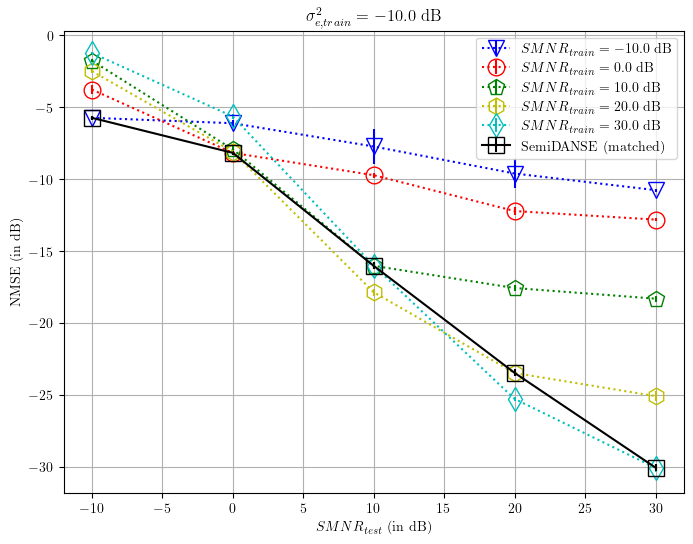

In [17]:
kappas = np.array([-10.0, 0.0, 10.0, 20.0, 30.0])
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})
plt.figure(figsize=(8,6))
plt.errorbar(
    kappas,
    metrics_semidanse_smnr_minus_10_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=3)
    yerr=metrics_semidanse_smnr_minus_10_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=3),
    fmt='bv:',
    fillstyle='none',
    ms=12,
    label='$SMNR_{train} = -10.0 $ dB'
)
plt.errorbar(
    kappas,
    metrics_semidanse_smnr_0_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=3)
    yerr=metrics_semidanse_smnr_0_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=3),
    fmt='ro:',
    fillstyle='none',
    ms=12,
    label='$SMNR_{train} = 0.0 $ dB'
)
plt.errorbar(
    kappas,
    metrics_semidanse_smnr_10_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=3)
    yerr=metrics_semidanse_smnr_10_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=3),
    fmt='gp:',
    fillstyle='none',
    ms=12,
    label='$SMNR_{train} = 10.0 $ dB'
)
plt.errorbar(
    kappas,
    metrics_semidanse_smnr_20_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=3)
    yerr=metrics_semidanse_smnr_20_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=3),
    fmt='yh:',
    fillstyle='none',
    ms=12,
    label='$SMNR_{train} = 20.0 $ dB'
)
plt.errorbar(
    kappas,
    metrics_semidanse_smnr_30_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=3)
    yerr=metrics_semidanse_smnr_30_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=3),
    fmt='cd:',
    fillstyle='none',
    ms=12,
    label='$SMNR_{train} = 30.0 $ dB'
)
plt.errorbar(
    kappas,
    metrics_semidanse_smnr_10_matched_multidimmat[0,-1,:], # nmse for SemiDANSE (nusp=3)
    yerr=metrics_semidanse_smnr_10_matched_multidimmat[1,-1,:], # nmse_std for SemiDANSE (nusp=3),
    fmt='ks-',
    fillstyle='none',
    ms=12,
    label='SemiDANSE (matched)'
)
plt.grid(True)
plt.xlabel('$SMNR_{test}$ (in dB)', usetex=True)
plt.ylabel('NMSE (in dB)', usetex=True)
plt.title('${\sigma}_{e,{train}}^2 = -10.0$ dB', usetex=True)
plt.legend()
tikzplotlib.save('../figs_new_{}_diff_smnr_dB/{}/nmse_vs_smnr_diff_train_SMNR.tex'.format(date, dirname))
plt.show()